## we will solve conditional with quadratic equation    a^2+bx+c  if d>0 2 real roots   if d==0  1 repeated root else d<0  no real root

In [20]:
import os
from dotenv import load_dotenv
load_dotenv()
from langgraph.graph import START,END,StateGraph
from typing import  TypedDict,Annotated,Literal
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
import operator 
import json

In [3]:
llm=ChatGroq(model='qwen/qwen3-32b',api_key=os.getenv('Groq_API_KEY'))   

In [4]:
class Equation(TypedDict):
  a:float 
  b:float
  c:float
  d:float
  eq:str
  result:str


In [12]:
def show_eq(state:Equation)->Equation:
    state['eq']=f"{state['a']}x^2 + {state['b']}x + {state['c']} = 0"
    return {'eq':state['eq']}

In [13]:
def compute_d(state:Equation)->Equation:
    state['d']= state['b']**2 - 4*state['a']*state['c']
    return {'d':state['d']}

In [14]:
def real_roots(state:Equation)->Equation:
    root1=(-state['b'] + state['d']**0.5)/(2*state['a'])
    root2=(-state['b'] - state['d']**0.5)/(2*state['a'])
     
    state['result']=f"Roots are {root1} and {root2}"
    return {'result':state['result']}

In [15]:
def repeated_root(state:Equation)->Equation:
    root=-state['b']/(2*state['a'])
    state['result']=f"Repeated root is {root}"
    return {'result':state['result']}

In [ ]:
def no_real_roots(state:Equation)->Equation:
    state['result']="No real roots"
    return {'result':state['result']}

In [24]:
def check_condition(state:Equation)->Literal["real_roots","repeated_root","no_real_roots"]:
    if state['d']>0:
        return 'real_roots'
    elif state['d']==0:
        return 'repeated_root'
    else:
        return 'no_real_roots'


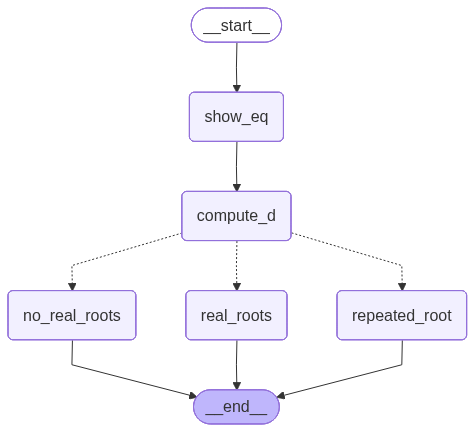

In [25]:
graph=StateGraph(Equation)
graph.add_node('show_eq',show_eq)
graph.add_node('compute_d',compute_d)
graph.add_node('real_roots',real_roots)
graph.add_node('repeated_root',repeated_root)
graph.add_node('no_real_roots',no_real_roots)

graph.add_edge(START,'show_eq')
graph.add_edge('show_eq','compute_d')
graph.add_edge('compute_d',END)
graph.add_conditional_edges('compute_d',check_condition)
graph.add_edge('real_roots',END)
graph.add_edge('repeated_root',END)
graph.add_edge('no_real_roots',END)
workflow= graph.compile()   
workflow


In [30]:
workflow.invoke({'a':2,'b':4,'c':2})

{'a': 2,
 'b': 4,
 'c': 2,
 'd': 0,
 'eq': '2x^2 + 4x + 2 = 0',
 'result': 'Repeated root is -1.0'}